In [24]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch
from scipy.special import logit, expit
from datetime import datetime

import pickle
from pathlib import Path

import sys
base_path = Path.cwd().parents[0]
sys.path.insert(0, str(base_path / '2_Propensities'))
sys.path.insert(0, str(base_path / '4_Baselines' / '4.1_Matrix_Factorization'))

import SASRec_class as sasrec
import MF_class as MF

# 1 Choosing Dataset

In [25]:
datasets = ['ml-1m', 'steam', 'goodreads', 'ml-10m']
DATASET = datasets[1]

print(f"Using dataset: {DATASET}")

Using dataset: steam


# 2 Loading Dataset and Propensities Model

In [ ]:
base_artifacts = Path.cwd().resolve().parents[1] / 'CausalI2I_artifacts'
data_path = base_artifacts / 'Datasets' / 'Processed' / DATASET
data = pd.read_csv(data_path / 'data_clean.csv')

with open(data_path / 'item_dict.pkl', 'rb') as f:
    item_dict = pickle.load(f)
title2id = {v: k for k, v in item_dict.items()}

with open(base_artifacts / 'Chosen_Pairs' / DATASET / 'chosen_pairs_ids.pkl', 'rb') as f:
    chosen_pairs_ids = pickle.load(f)

chosen_pairs_dict = {pair: i for i, pair in enumerate(chosen_pairs_ids)}

In [27]:
SR_model_path = base_artifacts / 'SASRec_Models' / f'{DATASET}'
with open(SR_model_path / f'init_dict.pkl', 'rb') as f:
    init_dict_loaded = pickle.load(f)
sasrec_model = sasrec.SASRecTorch(**init_dict_loaded)
sasrec_model.load(SR_model_path / f'sasrec.pt')
L = init_dict_loaded['max_seq_len']

Model loaded from /home/gouni/CausalI2I_new_artifacts/SASRec_Models/steam/sasrec.pt.
num_items:     12435
max_seq_len:   50
device:        cuda
batch_size:    2048
lr:            0.001
weight_decay:  0.0
num_epochs:    20
saved_at:      2026-07-15 12:11:58
note:          None


/home/gouni/.local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [28]:
MF_model_path = base_artifacts / 'MF_Models'

with open(MF_model_path / f'MF_params_{DATASET}.pkl', 'rb') as f:
    loaded_params = pickle.load(f)

MF_model = MF.MatrixFactorizationTorch(
    n_users=loaded_params['n_users'], 
    n_items=loaded_params['n_items'], 
    n_factors=loaded_params['n_factors']
)

model_name = f'MF_model_{DATASET}'
MF_model.load(path=MF_model_path / (model_name + '.pt'))
MF_model.eval()

Loaded model summary:
Model:                      MatrixFactorizationTorch
Number of users:            8364
Number of items:            12434
Number of factors:          50
Learning rate:              0.002
Weight decay:               1e-07
Positive weight:            1
Batch size:                 65536
Number of epochs:           30
Device:                     cuda:0
Use AMP:                    True
Timestamp:                  2026-08-07 08:27:06


MatrixFactorizationTorch()

# 3 Processing ChatGPT Response

In [29]:
folder = base_artifacts / 'API_Results' / DATASET
csvs_in_folder = [p.name for p in folder.iterdir() if p.is_file() and p.suffix == '.csv']
oracle_file_name = csvs_in_folder[-1]

print(f"Using oracle file: {oracle_file_name}")
oracle = pd.read_csv(folder / oracle_file_name)

oracle = oracle.copy()
oracle[["cause_id", "effect_id"]] = np.asarray(chosen_pairs_ids)

pd.DataFrame(oracle['causal_effect'].value_counts()).sort_index()

Using oracle file: causal_scores_final_2026-07-20.csv


,count
causal_effect,
0,8139
1,712
2,452
3,697


# 4 Defining Baselines

In [30]:
data['interaction'] = 1
pivot_real = data.pivot(index='user_id', columns='item_id', values='interaction').fillna(0)
itemid_to_colidx_pivot_real = {item_id: col_idx for col_idx, item_id in enumerate(pivot_real.columns)}
pivot_real_np = pivot_real.values

Q_normalized = (MF_model.Q / torch.norm(MF_model.Q, dim=1, keepdim=True)).cpu().detach().numpy()

def cosimilarity(idx1, idx2):
    """Calculate cosine similarity between two items."""
    return np.dot(Q_normalized[idx1], Q_normalized[idx2])

def correlation(idx1, idx2):
    """Calculate correlation between two items."""
    colidx1 = itemid_to_colidx_pivot_real[idx1]
    colidx2 = itemid_to_colidx_pivot_real[idx2]
    T = pivot_real_np[:, colidx1]
    Y = pivot_real_np[:, colidx2]
    if T.std() == 0 or Y.std() == 0:
        return 0
    return np.corrcoef(T, Y)[0, 1]

def diff_of_conditionals(idx1, idx2):
    """Calculate difference of conditionals P(Y|T) - P(Y|~T) between two items."""
    colidx1 = itemid_to_colidx_pivot_real[idx1]
    colidx2 = itemid_to_colidx_pivot_real[idx2]
    T = pivot_real_np[:, colidx1]
    Y = pivot_real_np[:, colidx2]
    p_T = np.clip(np.mean(T), 1e-6, 1-1e-6)
    p_Y = np.mean(Y)
    p_TY = np.mean(T * Y)
    return p_TY / p_T - (p_Y - p_TY) / (1 - p_T)

def jacard_index(idx1, idx2):
    """Calculate Jaccard index between two items."""
    colidx1 = itemid_to_colidx_pivot_real[idx1]
    colidx2 = itemid_to_colidx_pivot_real[idx2]
    T = pivot_real_np[:, colidx1]
    Y = pivot_real_np[:, colidx2]
    intersection = np.sum((T > 0) & (Y > 0))
    union = np.sum((T > 0) | (Y > 0))
    if union == 0:
        return 0
    return intersection / union

# 5 Defining ATE

In [31]:
window_path = base_artifacts / 'SASRec_Models' / f'{DATASET}' / f'evaluation_data.pkl'
with open(window_path, 'rb') as f:
    ATE_window_data = pickle.load(f)

A_to_unique_A_idx = ATE_window_data['A_to_unique_A_idx']
treatment_items = ATE_window_data['treatment_items']
future_items  = ATE_window_data['future_items']
calibrated_logits_matrix = ATE_window_data['calibrated_logits_matrix']

In [32]:
def get_ATE(T, Y, pi, stabilized=False,):
    """
    Estimate ATE using IPW

    Parameters
    ----------
    - T : Treatment assignment array.
    - Y : Outcome array.
    - pi : Propensity score array.
    - stabilized : Whether to use stabilized weights in the IPW estimation. Default is False.
    """

    # --------------------------------------------------
    # IPW components 
    # --------------------------------------------------

    D1 = T / pi
    D0 = (1 - T) / (1 - pi)
    N1 = Y * D1
    N0 = Y * D0

    mN1 = N1.mean()
    mN0 = N0.mean()
    mD1 = D1.mean()
    mD0 = D0.mean()

    ESS_1 = (D1.sum() ** 2) / (np.sum(D1 ** 2) + 1e-12)
    ESS_0 = (D0.sum() ** 2) / (np.sum(D0 ** 2) + 1e-12)
    ESS_ATE = 2.0 / (1.0 / (ESS_1 + 1e-12) + 1.0 / (ESS_0 + 1e-12))

    # --------------------------------------------------
    # Point estimate
    # --------------------------------------------------

    eps = 1e-12
    if stabilized:
        term_1 = mN1 / (mD1 + eps)
        term_0 = mN0 / (mD0 + eps)
    else:
        term_1 = mN1
        term_0 = mN0
    
    ATE =  term_1 - term_0

    # --------------------------------------------------
    # Variance (delta method)
    # --------------------------------------------------

    n = len(T)
    if stabilized:
        Z = np.column_stack([N1, D1, N0, D0])
        g = np.array([
            1.0 / (mD1 + eps),
            -mN1 / ((mD1 + eps)**2),
            -1.0 / (mD0 + eps),
            mN0 / ((mD0 + eps)**2),
        ])
        S = np.cov(Z, rowvar=False, ddof=1)
        var_hat = (g @ S @ g) / n

    else:
        Z = np.column_stack([N1, N0])
        g = np.array([1.0, -1.0])
        S = np.cov(Z, rowvar=False, ddof=1)
        var_hat = (g @ S @ g) / n

    STD = float(np.sqrt(max(var_hat, 0.0)))

    return {
        "ATE": ATE, 
        "STD": STD,
        "size": n,
        "ESS_0": ESS_0,
        "ESS_1": ESS_1,
        "ESS_ATE": ESS_ATE,
    }

In [33]:
def get_ATE_wrapper(
    cause_item,
    effect_item,
    clip=0,
):
    """
    Estimate ATE using IPW

    Parameters
    ----------
    - cause_item : The item ID of the cause item.
    - effect_item : The item ID of the effect item.
    - clip : The clipping value for propensity scores to avoid extreme weights. Default is 0 (no clipping).
    - stabilized : Whether to use stabilized weights in the IPW estimation. Default is False.    
    """

    # -------------------------------------------------------------------
    # Calculate treatment and outcome variables, and propensity scores
    # -------------------------------------------------------------------

    T = treatment_items == cause_item
    Y = np.any(future_items == effect_item, axis=1)
    
    pi = expit(
        calibrated_logits_matrix[:, A_to_unique_A_idx[cause_item]]
    )
    pi = np.clip(pi, clip, 1 - clip)

    # --------------------------------------------------
    # Estimate ATE using IPW
    # --------------------------------------------------

    Horvitz_Thompson = get_ATE(T, Y, pi, stabilized=False)

    Hájek = get_ATE(T, Y, pi, stabilized=True)

    ablt_pi = 0.5 * np.ones_like(pi)
    ablation = get_ATE(T, Y, ablt_pi, stabilized=True)

    return {
        "ATE": Horvitz_Thompson["ATE"],
        "STD": Horvitz_Thompson["STD"],
        "ATE_STABILIZED": Hájek["ATE"],
        "STD_STABILIZED": Hájek["STD"],
        "ATE_ABLT": ablation["ATE"],
        "STD_ABLT": ablation["STD"],
        "size": Horvitz_Thompson["size"],
        "ESS_0": Horvitz_Thompson["ESS_0"],
        "ESS_1": Horvitz_Thompson["ESS_1"],
        "ESS_ATE": Horvitz_Thompson["ESS_ATE"],
    }

# 6 Generate Results

In [34]:
clip_dict = {
    'ml-1m': 1e-3,
    'steam': 0.0,
    'goodreads': 2e-3,
    'ml-10m': 5e-3,
}

clip = clip_dict[DATASET]

In [35]:
def process_pair(pair):

    ate_dict = get_ATE_wrapper(pair[0], pair[1], clip=clip)
    
    return {
        "cause_id": pair[0],
        "effect_id": pair[1],
        "ATE": ate_dict["ATE"],
        "STD": ate_dict["STD"],
        "size": ate_dict["size"],
        "ESS_0": ate_dict["ESS_0"],
        "ESS_1": ate_dict["ESS_1"],
        "ESS_ATE": ate_dict["ESS_ATE"],
        "ATE_ABLT": ate_dict["ATE_ABLT"],
        "STD_ABLT": ate_dict["STD_ABLT"],
        "ATE_STABILIZED": ate_dict["ATE_STABILIZED"],
        "STD_STABILIZED": ate_dict["STD_STABILIZED"],
        "cosine_similarity": cosimilarity(*pair),
        "correlation": correlation(*pair),
        "diff_of_conditionals": diff_of_conditionals(*pair),
        "jacard_index": jacard_index(*pair),
    }

In [36]:
from joblib import Parallel, delayed

all_results = Parallel(
    n_jobs=24,
    prefer="threads",
    return_as="generator_unordered",
)(
    delayed(process_pair)(pair)
    for pair in chosen_pairs_ids
)

all_results = tqdm(
    all_results,
    total=len(chosen_pairs_ids),
    smoothing=0.01,
)

raw_results = pd.DataFrame(all_results)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [37]:
merged = pd.merge(
    left=oracle,
    right=raw_results,
    on=["cause_id", "effect_id"],
    how="inner",
)

merged.to_csv(base_artifacts / 'Datasets' / 'Evaluated' / f'{DATASET}_evaluated.csv', index=False)

In [38]:
overlap_pairs = merged[merged['causal_effect'] > 0][['cause_id', 'effect_id']].apply(tuple, axis=1).to_list()

In [39]:
results = {}
for cause_item, effect_item in tqdm(overlap_pairs):
    T = treatment_items == cause_item
    Y = np.any(future_items == effect_item, axis=1)
    
    pi = expit(
        calibrated_logits_matrix[:, A_to_unique_A_idx[cause_item]]
    )
    # pi = np.clip(pi, clip, 1 - clip)

    pi_T = pi[T]
    Y_T = Y[T]

    results[(cause_item, effect_item)] = {
        "EYT1": np.mean(Y_T) if np.sum(T) > 0 else 0,
        "ATT": np.mean(Y_T / pi_T) if np.sum(T) > 0 else 0,
        "ATTs": np.mean(Y_T / pi_T) / max(np.mean(pi_T ** -1), 1e-8) if np.sum(T) > 0 else 0,
        "CORR" : np.corrcoef(pi_T ** -1, Y_T)[0, 1] if np.sum(T) > 2 and np.any(Y_T) and np.any(~Y_T) else 0
    }

  0%|          | 0/1861 [00:00<?, ?it/s]

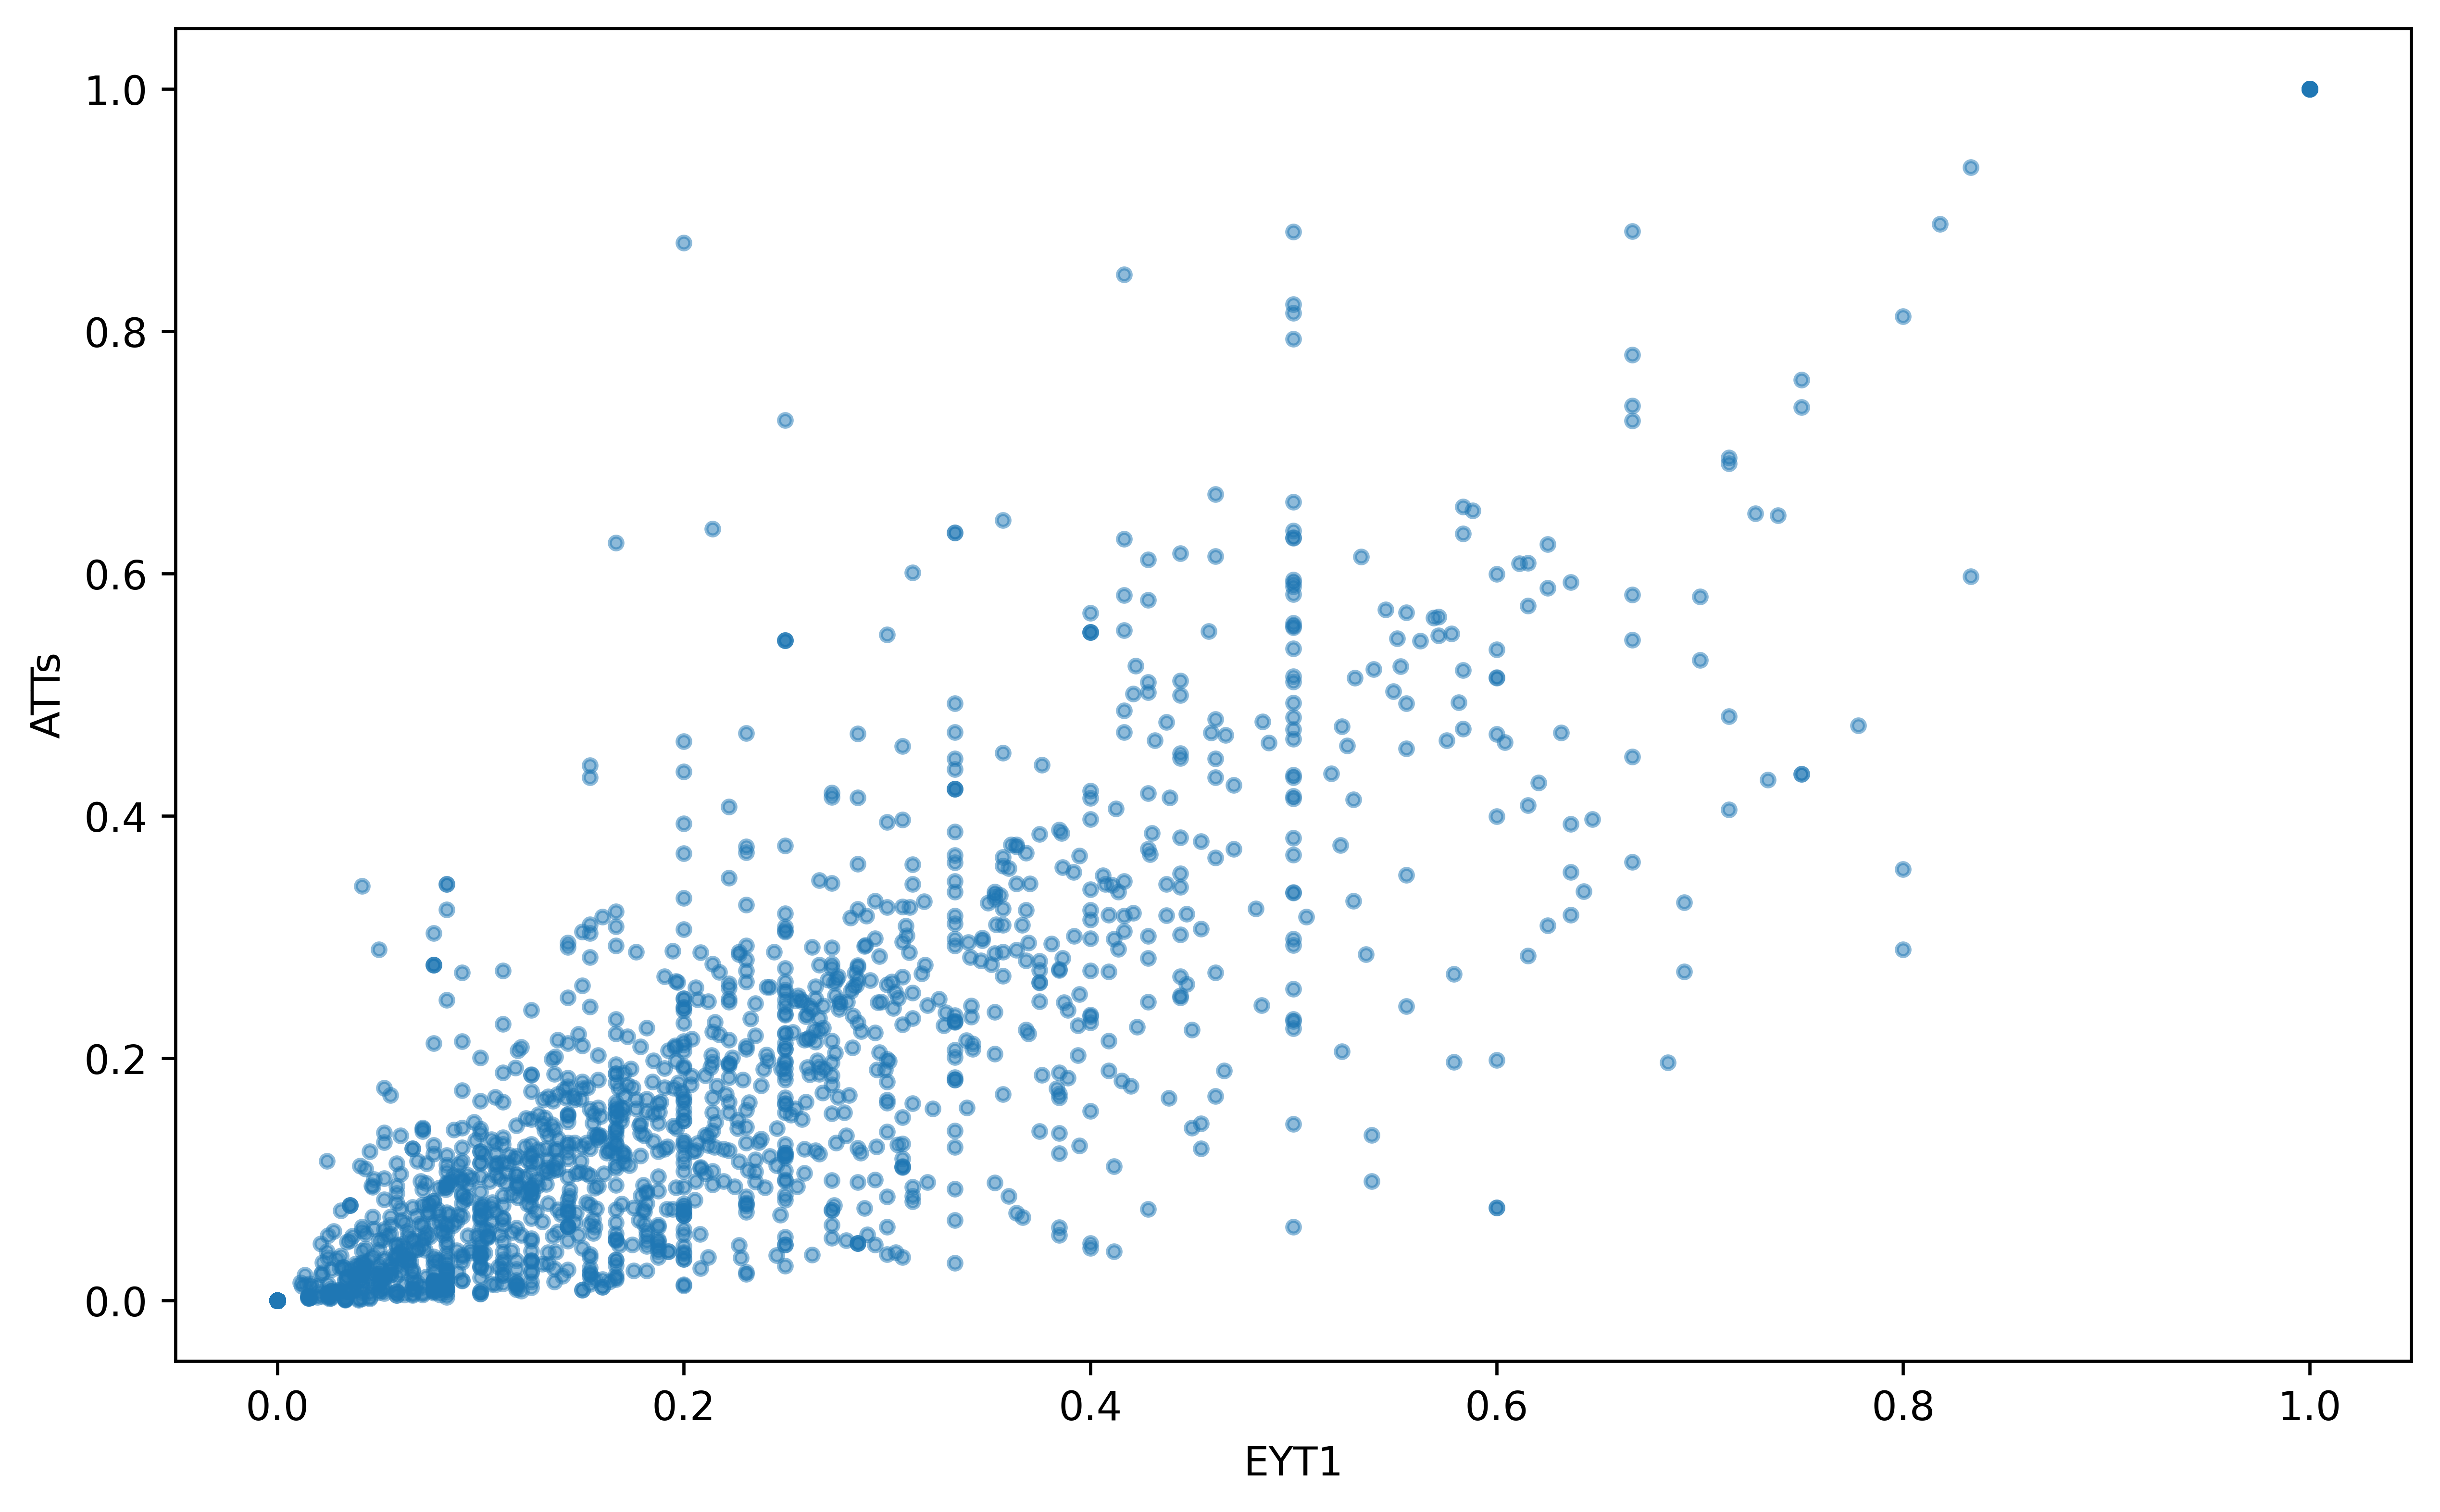

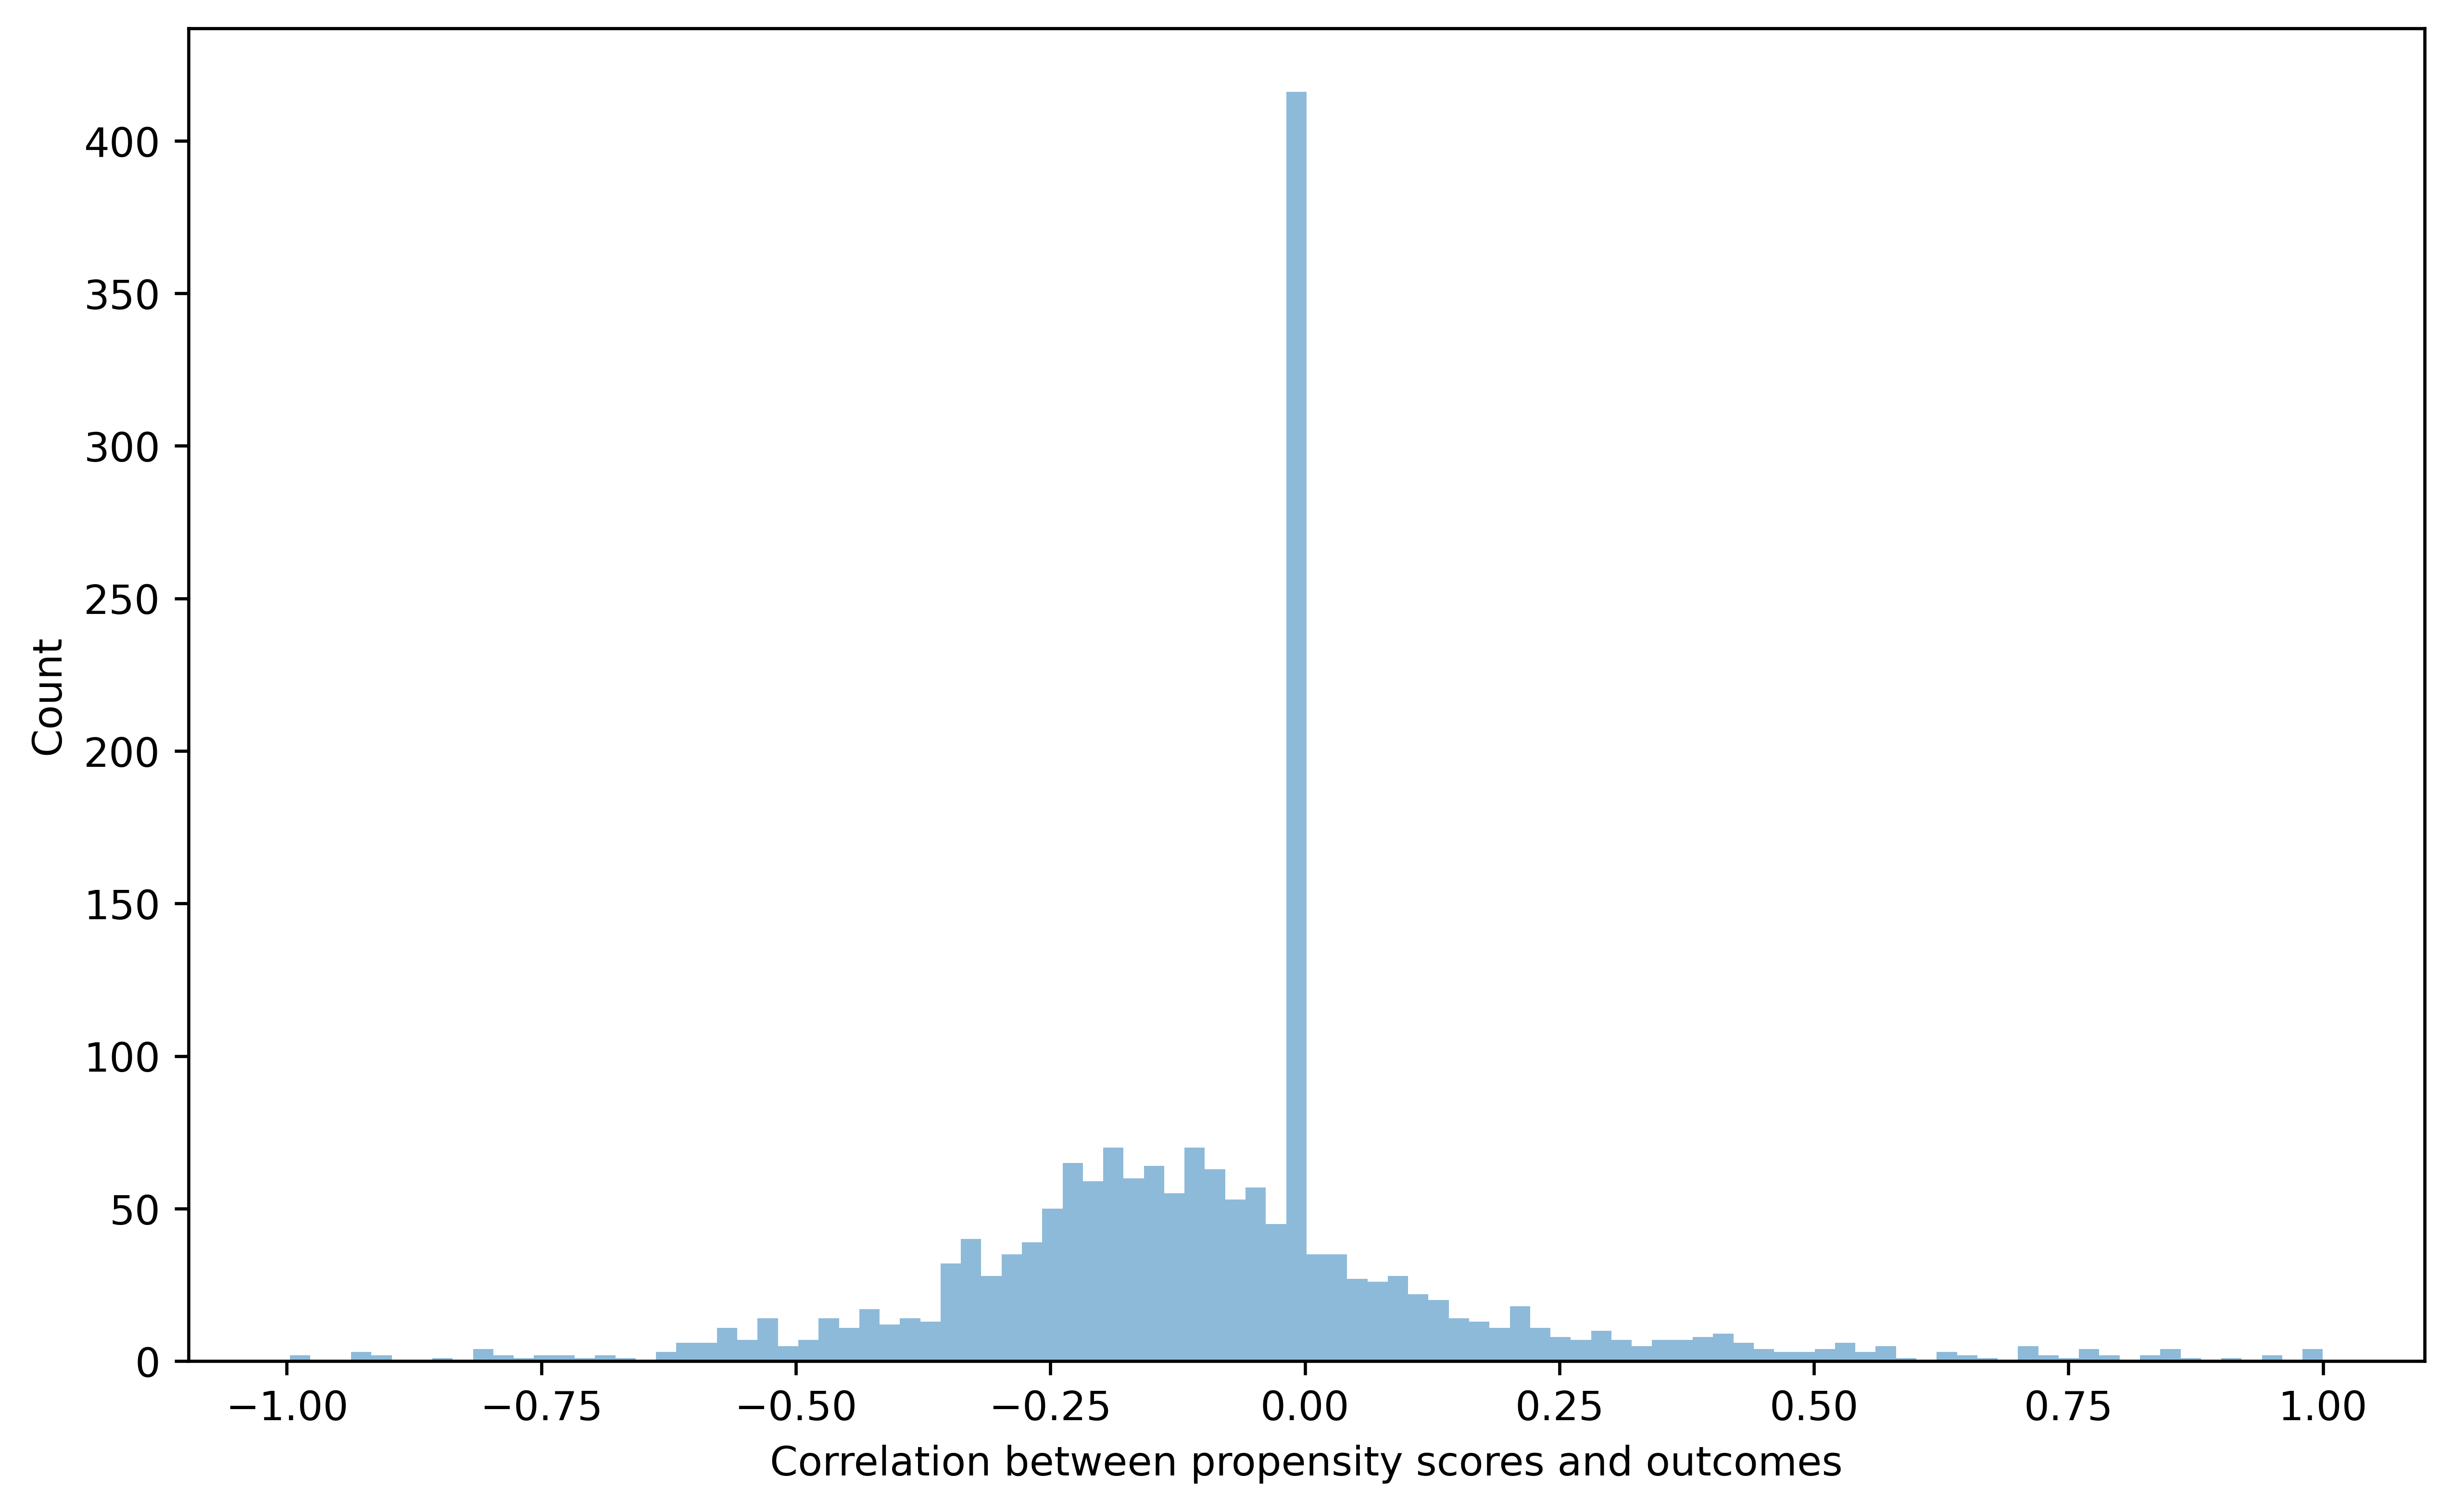

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6), dpi=600)
plt.scatter(
    [v["EYT1"] for v in results.values()],
    [v["ATTs"] for v in results.values()],
    s=10,
    alpha=0.5,
)
plt.xlabel("EYT1")
plt.ylabel("ATTs")
plt.show()

plt.figure(figsize=(10, 6), dpi=600)
plt.hist(
    [v["CORR"] for v in results.values()],
    bins=100,
    alpha=0.5,
    label="CORR"
)
plt.xlabel("Correlation between propensity scores and outcomes")
plt.ylabel("Count")
plt.show()